In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, make_scorer

# ==========================================
# 1. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ==========================================
print("Chargement des données...")
df = pd.read_csv('../datasets/nutriscore_donnees_propres_final.csv', sep=';')



Chargement des données...


C:\Users\titou\AppData\Local\Temp\ipykernel_18956\117683709.py:11: DtypeWarning: Columns (0: code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../datasets/nutriscore_donnees_propres_final.csv', sep=';')


In [3]:
# Séparation des features (X) et de la cible (y)
# On exclut les colonnes d'identification et la fuite de données (nutriscore_grade)
X = df.drop(columns=['code', 'product_name', 'nutriscore_score', 'nutriscore_grade'])
y = df['nutriscore_score']

# Astuce XGBoost : Convertir la colonne catégorielle en type 'category' de Pandas
# XGBoost gèrera nativement cette colonne sans encodage mathématique supplémentaire
X['main_category'] = X['main_category'].astype('category')

# ==========================================
# 2. CONFIGURATION DU MODÈLE XGBOOST
# ==========================================
print("Configuration du modèle XGBoost...")
# Paramètres de base pour un bon compromis entre vitesse et précision
xgb_model = xgb.XGBRegressor(
    n_estimators=150,           # Nombre d'arbres
    learning_rate=0.1,          # Taux d'apprentissage
    max_depth=7,                # Profondeur maximale de chaque arbre
    tree_method='hist',         # Méthode optimisée (très rapide pour les gros datasets)
    enable_categorical=True,    # Active le support natif des catégories
    random_state=42,
    n_jobs=-1                   # Utilise tous les cœurs du processeur
)



Configuration du modèle XGBoost...


In [4]:
# ==========================================
# 3. VALIDATION CROISÉE (CROSS-VALIDATION)
# ==========================================
print("Lancement de la validation croisée (5 Folds)...")
# On découpe les données en 5 morceaux (Folds) pour une évaluation robuste
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# On utilise l'Erreur Absolue Moyenne (MAE) pour évaluer
# (scikit-learn utilise des scores négatifs pour les métriques d'erreur par convention, d'où le 'neg_')
cv_scores = cross_val_score(
    xgb_model, 
    X, y, 
    cv=kf, 
    scoring='neg_mean_absolute_error',
    n_jobs=1 # Mis à 1 car XGBoost utilise déjà n_jobs=-1 en interne
)

# Conversion des scores négatifs en scores positifs
mae_scores = -cv_scores


Lancement de la validation croisée (5 Folds)...



RÉSULTATS DE LA VALIDATION CROISÉE
Fold 1 : MAE = 0.848 points
Fold 2 : MAE = 0.860 points
Fold 3 : MAE = 0.846 points
Fold 4 : MAE = 0.868 points
Fold 5 : MAE = 0.853 points
----------------------------------------
MAE Moyenne Globale : 0.855 points
Ecart-type (StDev)  : 0.008 points

Entraînement du modèle final sur 100% des données...

Importance des caractéristiques :
                      Variable  Importance
            saturated-fat_100g    0.356056
                   sugars_100g    0.222376
                   sodium_100g    0.182993
                      fat_100g    0.082700
                    fiber_100g    0.037970
                 proteins_100g    0.035524
fruits-vegetables-legumes_100g    0.035447
            carbohydrates_100g    0.022498
                 main_category    0.013080
                   energy_100g    0.011355


In [ ]:

# ==========================================
# 4. RÉSULTATS
# ==========================================
print("\n" + "="*40)
print("RÉSULTATS DE LA VALIDATION CROISÉE")
print("="*40)
for i, score in enumerate(mae_scores, 1):
    print(f"Fold {i} : MAE = {score:.3f} points")

print("-" * 40)
print(f"MAE Moyenne Globale : {np.mean(mae_scores):.3f} points")
print(f"Ecart-type (StDev)  : {np.std(mae_scores):.3f} points")
print("="*40)

# (Optionnel) Entraînement final sur toutes les données pour voir l'importance des variables
print("\nEntraînement du modèle final sur 100% des données...")
xgb_model.fit(X, y)

importances = pd.DataFrame({
    'Variable': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nImportance des caractéristiques :")
print(importances.to_string(index=False))



In [7]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

# ==========================================
# 1. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ==========================================
print("Chargement des données...")
df = pd.read_csv('../datasets/nutriscore_donnees_propres_final.csv', sep=';')

X = df.drop(columns=['code', 'product_name', 'nutriscore_score', 'nutriscore_grade'])
y = df['nutriscore_score']

# Remplacement des valeurs manquantes et conversion en texte
X['main_category'] = X['main_category'].fillna("INCONNU").astype(str)

# Liste des variables catégorielles
cat_features = ['main_category']

# ==========================================
# 2. VALIDATION CROISÉE MANUELLE (KFold)
# ==========================================
print("Lancement de la validation croisée (5 Folds)...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

mae_scores = []

# On boucle manuellement sur chaque découpage
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    
    # Séparation Train / Test pour ce fold
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Initialisation du modèle SANS le paramètre cat_features
    cat_model = CatBoostRegressor(
        iterations=200,
        learning_rate=0.1,
        depth=6,
        random_seed=42,
        verbose=0,
        thread_count=-1
    )
    
    # Entraînement : C'EST ICI qu'on précise les variables catégorielles
    cat_model.fit(X_train, y_train, cat_features=cat_features)
    
    # Prédiction sur l'échantillon de test
    y_pred = cat_model.predict(X_test)
    
    # Évaluation
    mae = mean_absolute_error(y_test, y_pred)
    mae_scores.append(mae)
    print(f"Fold {fold} terminé : MAE = {mae:.3f} points")

# ==========================================
# 3. RÉSULTATS
# ==========================================
print("\n" + "="*40)
print("RÉSULTATS DE LA VALIDATION CROISÉE")
print("="*40)
print(f"MAE Moyenne Globale : {np.mean(mae_scores):.3f} points")
print(f"Ecart-type (StDev)  : {np.std(mae_scores):.3f} points")
print("="*40)

# ==========================================
# 4. ENTRAÎNEMENT FINAL (Sur 100% des données)
# ==========================================
print("\nEntraînement du modèle final sur 100% des données...")
final_model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=0,
    thread_count=-1
)
# On passe à nouveau cat_features dans le fit()
final_model.fit(X, y, cat_features=cat_features)

importances = pd.DataFrame({
    'Variable': X.columns,
    'Importance': final_model.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

print("\nImportance des caractéristiques :")
print(importances.to_string(index=False))

Chargement des données...


C:\Users\titou\AppData\Local\Temp\ipykernel_18956\3505678086.py:11: DtypeWarning: Columns (0: code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../datasets/nutriscore_donnees_propres_final.csv', sep=';')


Lancement de la validation croisée (5 Folds)...
Fold 1 terminé : MAE = 0.971 points
Fold 2 terminé : MAE = 0.966 points
Fold 3 terminé : MAE = 0.972 points
Fold 4 terminé : MAE = 0.986 points
Fold 5 terminé : MAE = 0.969 points

RÉSULTATS DE LA VALIDATION CROISÉE
MAE Moyenne Globale : 0.973 points
Ecart-type (StDev)  : 0.007 points

Entraînement du modèle final sur 100% des données...

Importance des caractéristiques :
                      Variable  Importance
                   sugars_100g   27.133331
                   sodium_100g   23.825982
            saturated-fat_100g   21.071738
                    fiber_100g    6.079506
                 proteins_100g    5.014692
                   energy_100g    4.795762
                      fat_100g    4.069286
                 main_category    4.025549
fruits-vegetables-legumes_100g    3.253168
            carbohydrates_100g    0.730987


Calcul de la courbe d'apprentissage pour XGBoost...


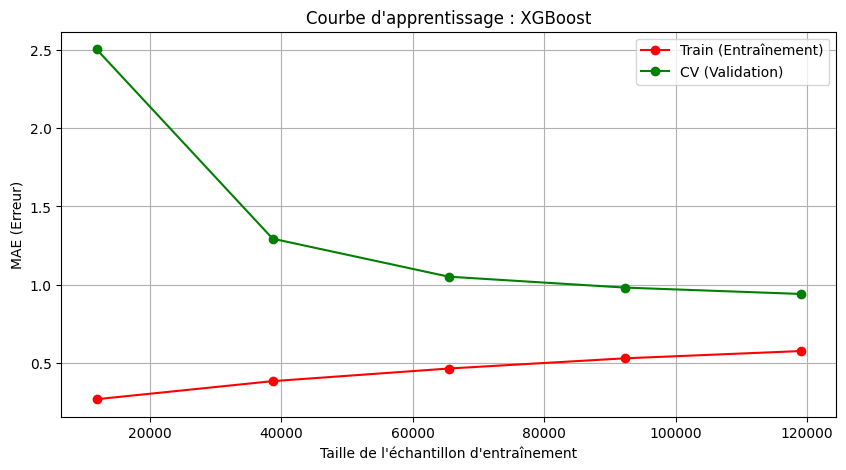

Calcul de la courbe d'apprentissage pour CatBoost...


IndexError: list index out of range

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
from catboost import CatBoostRegressor

def plot_learning_curves(estimator, X, y, title):
    print(f"Calcul de la courbe d'apprentissage pour {title}...")
    
    # Calcul des scores
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, 
        cv=5, 
        scoring='neg_mean_absolute_error',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    # Conversion en scores positifs (MAE)
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)

    # Graphique
    plt.figure(figsize=(10, 5))
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Train (Entraînement)")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="CV (Validation)")
    
    plt.title(f"Courbe d'apprentissage : {title}")
    plt.xlabel("Taille de l'échantillon d'entraînement")
    plt.ylabel("MAE (Erreur)")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

# --- 1. COURBE POUR XGBOOST ---
# On s'assure que le type est bien 'category' pour XGBoost
X_xgb = X.copy()
X_xgb['main_category'] = X_xgb['main_category'].astype('category')
plot_learning_curves(xgb_model, X_xgb, y, "XGBoost")



Calcul de la courbe d'apprentissage pour CatBoost (Mode compatibilité)...


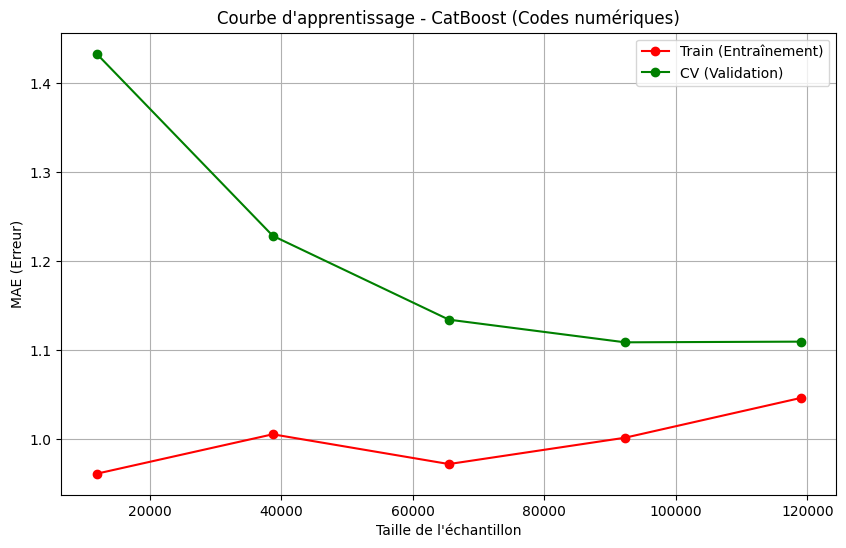

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
from catboost import CatBoostRegressor

def plot_learning_curves_catboost_fixed(X, y):
    print("Calcul de la courbe d'apprentissage pour CatBoost (Mode compatibilité)...")
    
    # 1. Préparation des données : Encodage numérique simple
    # Cela évite d'utiliser l'argument cat_features qui fait planter le clone
    X_encoded = X.copy()
    if 'main_category' in X_encoded.columns:
        X_encoded['main_category'] = X_encoded['main_category'].astype('category').cat.codes
    
    # 2. Configuration du modèle "standard"
    # On ne mentionne PAS cat_features ici pour éviter l'erreur de clonage
    cat_model_lc = CatBoostRegressor(
        iterations=200,
        learning_rate=0.1,
        depth=6,
        random_seed=42,
        verbose=0,
        thread_count=-1
    )

    # 3. Calcul des scores (n_jobs=1 reste recommandé)
    train_sizes, train_scores, test_scores = learning_curve(
        cat_model_lc, X_encoded, y, 
        cv=5, 
        scoring='neg_mean_absolute_error',
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=1 
    )

    # 4. Tracé
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Train (Entraînement)")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="CV (Validation)")
    
    plt.title("Courbe d'apprentissage - CatBoost (Codes numériques)")
    plt.xlabel("Taille de l'échantillon")
    plt.ylabel("MAE (Erreur)")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

# Appel de la fonction
plot_learning_curves_catboost_fixed(X, y)